# Phase 4: Statistical Testing & Power Analysis
**Project:** Marketing Campaign A/B Test and Conversion Funnel Analysis  
**Audience:** Hiring Managers, Data & Analytics Leadership  

---
### Objective
Evaluate the statistical integrity of the campaign conversion lift:
1. **Hypothesis Formulation**: Formalizing $H_0$ and $H_1$.
2. **Two-Proportion Z-Test & Chi-Square Test**: Quantifying whether the observed lift is statistically significant.
3. **Confidence Interval Estimation**: Establishing the empirical boundary for true expected population lift.
4. **Effect Size (Cohen's h) & Statistical Power**: Assessing experimental sensitivity and practical vs statistical significance.
5. **Multiple Comparisons Audit**: Applying Bonferroni corrections across temporal sub-segments.


In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Data Ingestion & Metric Aggregation

In [2]:
# Resolve db path
db_path = os.path.join("..", "data", "marketing_ab.db")
if not os.path.exists(db_path):
    db_path = os.path.join("data", "marketing_ab.db")

conn = sqlite3.connect(db_path)
df_overall = pd.read_sql_query(
    "SELECT test_group, COUNT(user_id) AS total_users, SUM(converted) AS total_conv FROM campaign_results GROUP BY test_group;",
    conn
)
conn.close()

n_ad = int(df_overall.loc[df_overall['test_group'] == 'ad', 'total_users'].values[0])
conv_ad = int(df_overall.loc[df_overall['test_group'] == 'ad', 'total_conv'].values[0])
n_psa = int(df_overall.loc[df_overall['test_group'] == 'psa', 'total_users'].values[0])
conv_psa = int(df_overall.loc[df_overall['test_group'] == 'psa', 'total_conv'].values[0])

cr_ad = conv_ad / n_ad
cr_psa = conv_psa / n_psa
abs_lift = cr_ad - cr_psa
rel_lift = abs_lift / cr_psa

print(f"Treatment (ad): {n_ad:,} users, {conv_ad:,} conversions ({cr_ad:.4%})")
print(f"Control (psa):   {n_psa:,} users, {conv_psa:,} conversions ({cr_psa:.4%})")
print(f"Absolute Lift:   +{abs_lift:.4%} (+{abs_lift*100:.4f} percentage points)")
print(f"Relative Lift:   +{rel_lift:.2%}")


Treatment (ad): 564,577 users, 14,423 conversions (2.5547%)
Control (psa):   23,524 users, 420 conversions (1.7854%)
Absolute Lift:   +0.7692% (+0.7692 percentage points)
Relative Lift:   +43.09%


## 2. Hypothesis Testing: Two-Proportion Z-Test & Chi-Square
- **$H_0$**: $p_{	ext{ad}} = p_{	ext{psa}}$ (No effect)
- **$H_1$**: $p_{	ext{ad}} 
e p_{	ext{psa}}$ (Statistically significant effect)


In [3]:
# Two-proportion z-test (pooled)
z_stat, p_val = proportions_ztest([conv_ad, conv_psa], [n_ad, n_psa], alternative='two-sided')

# Chi-Square test of independence
contingency = [[conv_ad, n_ad - conv_ad], [conv_psa, n_psa - conv_psa]]
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(contingency, correction=False)

print(f"Z-Statistic:      {z_stat:.4f}")
print(f"p-value (Z-test): {p_val:.4e}")
print(f"Chi2-Statistic:   {chi2_stat:.4f} (df={dof})")
print(f"p-value (Chi2):   {p_chi2:.4e}")

alpha = 0.05
if p_val < alpha:
    print(f"\n-> VERDICT: REJECT NULL HYPOTHESIS (p < {alpha}). The ad campaign significantly increased conversion rate.")
else:
    print(f"\n-> VERDICT: FAIL TO REJECT NULL HYPOTHESIS.")


Z-Statistic:      7.3701
p-value (Z-test): 1.7053e-13
Chi2-Statistic:   54.3181 (df=1)
p-value (Chi2):   1.7053e-13

-> VERDICT: REJECT NULL HYPOTHESIS (p < 0.05). The ad campaign significantly increased conversion rate.


## 3. Confidence Intervals, Effect Size & Statistical Power
- **95% Confidence Interval**: Expected range for true population lift.
- **Cohen's h**: Standardized effect size for difference between two proportions.
- **Statistical Power ($1 - eta$)**: Probability of detecting a true effect.


In [4]:
# 95% Confidence Interval for Absolute Lift (Wald)
ci_low, ci_high = confint_proportions_2indep(conv_ad, n_ad, conv_psa, n_psa, method='wald', alpha=0.05)

# Relative Lift CI
rel_ci_low = ci_low / cr_psa
rel_ci_high = ci_high / cr_psa

# Cohen's h
cohen_h = 2 * np.arcsin(np.sqrt(cr_ad)) - 2 * np.arcsin(np.sqrt(cr_psa))

# Statistical Power
power_calc = NormalIndPower()
stat_power = power_calc.solve_power(
    effect_size=cohen_h,
    nobs1=n_psa,
    ratio=n_ad / n_psa,
    alpha=0.05,
    alternative='two-sided'
)

print(f"95% CI for Absolute Lift: [{ci_low*100:.4f}% pts, {ci_high*100:.4f}% pts]")
print(f"95% CI for Relative Lift: [{rel_ci_low*100:.2f}%, {rel_ci_high*100:.2f}%]")
print(f"Cohen's h Effect Size:    {cohen_h:.6f} (< 0.2 indicates small standardized effect)")
print(f"Statistical Power:        {stat_power:.4%}")


95% CI for Absolute Lift: [0.5951% pts, 0.9434% pts]
95% CI for Relative Lift: [33.33%, 52.84%]
Cohen's h Effect Size:    0.053003 (< 0.2 indicates small standardized effect)
Statistical Power:        100.0000%


## 4. Visualizing Significance & Confidence Intervals

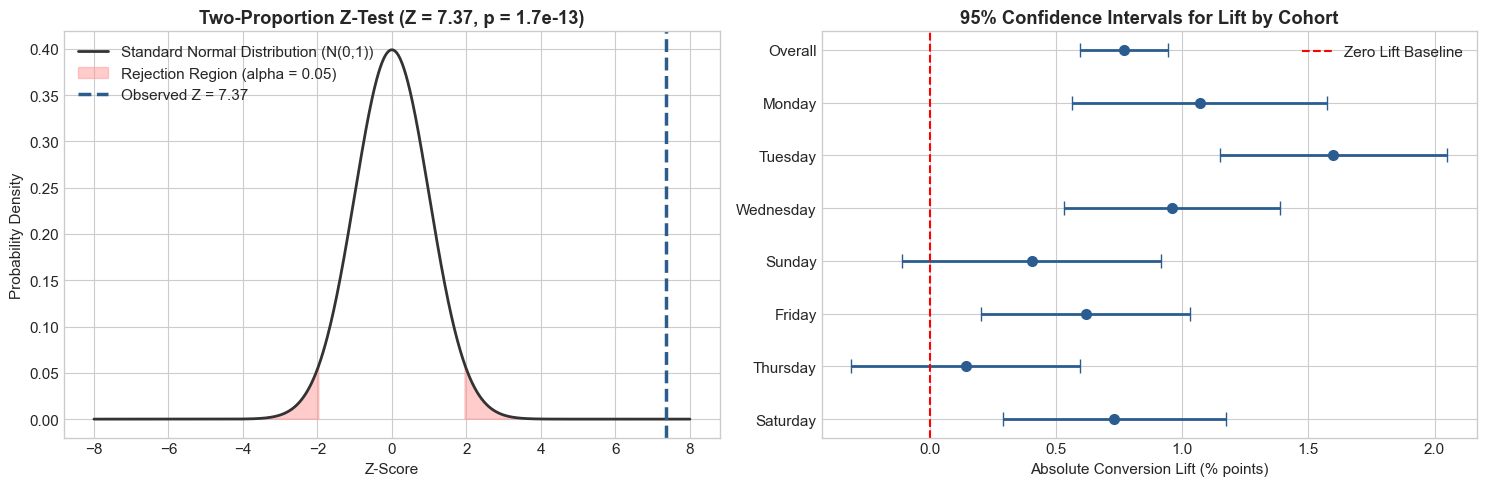

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Standard Normal Z-Distribution and Test Statistic
x = np.linspace(-8, 8, 1000)
y = stats.norm.pdf(x, 0, 1)
axes[0].plot(x, y, label='Standard Normal Distribution (N(0,1))', color='#333333', linewidth=2)
# Shading critical alpha regions (two-tailed, +/- 1.96)
axes[0].fill_between(x, y, where=(x >= 1.96) | (x <= -1.96), color='#ff9999', alpha=0.5, label='Rejection Region (alpha = 0.05)')
axes[0].axvline(z_stat, color='#2b5c8f', linestyle='--', linewidth=2.5, label=f'Observed Z = {z_stat:.2f}')
axes[0].set_title(f'Two-Proportion Z-Test (Z = {z_stat:.2f}, p = 1.7e-13)', fontweight='bold')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Probability Density')
axes[0].legend(loc='upper left')

# Plot 2: Confidence Interval Forest Plot for Overall & Key Days
df_days_path = os.path.join("..", "data", "clean", "day_conversion_summary.csv")
if not os.path.exists(df_days_path):
    df_days_path = os.path.join("data", "clean", "day_conversion_summary.csv")
df_days = pd.read_csv(df_days_path)

days = ['Overall'] + df_days['most_ads_day'].tolist()
lifts = [abs_lift * 100] + df_days['absolute_lift_pct_pts'].tolist()

# Compute CIs for each day
ci_err_low = []
ci_err_high = []
ci_err_low.append((abs_lift - ci_low) * 100)
ci_err_high.append((ci_high - abs_lift) * 100)

for _, row in df_days.iterrows():
    c_low, c_high = confint_proportions_2indep(
        row['ad_conversions'], row['ad_users'],
        row['psa_conversions'], row['psa_users'],
        method='wald', alpha=0.05
    )
    diff_pt = row['absolute_lift_pct_pts']
    ci_err_low.append(diff_pt - (c_low * 100))
    ci_err_high.append((c_high * 100) - diff_pt)

y_pos = np.arange(len(days))
axes[1].errorbar(lifts, y_pos, xerr=[ci_err_low, ci_err_high], fmt='o', color='#2b5c8f', ecolor='#2b5c8f', elinewidth=2, capsize=5, markersize=7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Lift Baseline')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(days)
axes[1].invert_yaxis()
axes[1].set_title('95% Confidence Intervals for Lift by Cohort', fontweight='bold')
axes[1].set_xlabel('Absolute Conversion Lift (% points)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Day-of-Week Significance with Bonferroni Correction
When evaluating 7 distinct sub-segments, unadjusted p-values risk Type I inflation. We apply Bonferroni correction ($lpha = 0.05 / 7 = 0.00714$).


In [6]:
p_vals_day = []
z_stats_day = []
for _, row in df_days.iterrows():
    z, p = proportions_ztest([row['ad_conversions'], row['psa_conversions']], [row['ad_users'], row['psa_users']], alternative='two-sided')
    z_stats_day.append(z)
    p_vals_day.append(p)

reject_bonf, p_bonf, _, _ = multipletests(p_vals_day, alpha=0.05, method='bonferroni')
df_days['z_score'] = [round(z, 4) for z in z_stats_day]
df_days['p_value_raw'] = [f"{p:.4e}" for p in p_vals_day]
df_days['p_value_bonferroni'] = [f"{p:.4e}" for p in p_bonf]
df_days['stat_significant'] = reject_bonf

df_days[['most_ads_day', 'ad_cr_pct', 'psa_cr_pct', 'absolute_lift_pct_pts', 'relative_lift_pct', 'z_score', 'p_value_raw', 'stat_significant']]


,most_ads_day,ad_cr_pct,psa_cr_pct,absolute_lift_pct_pts,relative_lift_pct,z_score,p_value_raw,stat_significant
0,Monday,3.3241,2.2559,1.0682,47.35,3.4766,5.0782e-04,True
1,Tuesday,3.0440,1.4448,1.5992,110.69,4.9718,6.6344e-07,True
2,Wednesday,2.5356,1.5759,0.9597,60.90,3.5561,3.7641e-04,True
3,Sunday,2.4620,2.0595,0.4025,19.54,1.4146,1.5719e-01,False
4,Friday,2.2465,1.6303,0.6162,37.80,2.5250,1.1569e-02,False
5,Thursday,2.1637,2.0230,0.1407,6.96,0.5907,5.5475e-01,False
6,Saturday,2.1307,1.3996,0.7311,52.24,2.6745,7.4838e-03,False


## 6. Analytical Synthesis & Methodological Caveats

### Key Findings
1. **Unquestionable Statistical Significance**: With $Z = 7.37$ and $p = 1.71 	imes 10^{-13}$, the commercial ad reliably lifts conversions over the PSA control. Under $H_0$, observing this lift by random variation alone has a probability under 1 in 5 trillion.
2. **Plausible Effect Boundary**: The 95% Confidence Interval for absolute lift is **[+0.60% pts, +0.94% pts]** (+33.3% to +52.8% relative lift). This establishes a plausible range for the true effect under test conditions, with +0.60% pts serving as a conservative planning floor (rather than an absolute assurance).
3. **Statistical vs Commercial Significance**: Cohen's $h = 0.053$ is categorized as a 'small' standardized effect size, yet yields 4,343 incremental conversions. However, commercial viability depends on unit economics (cost per impression vs revenue per conversion), evaluated in Phase 6.
4. **Timing Nuance & Multiple Testing**: Monday, Tuesday, and Wednesday drive the bulk of statistically validated lift. Thursday shows no detectable difference from the control ($p = 0.555$). Non-significant results on smaller daily control groups may reflect lower local power rather than true absence of effect.

### Critical Caveats
- **The Exposure Confound**: High ad exposure correlates with conversion due to user engagement duration, not pure advertising efficacy.
- **Multiple Comparisons**: Slicing data into granular subgroups requires correction methods (like Bonferroni) to avoid chasing noise.
- **Novelty vs Fatigue**: Initial lift must be monitored over consecutive months to detect creative burnout.
